<a href="https://colab.research.google.com/github/TramSt/decision-tree-pima-diabetes/blob/main/notebooks/02_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌳 Notebook 02 — Decision Tree Model
**Chủ đề 12:** Cây Quyết Định Phân Loại Bệnh Tiểu Đường (Pima Indians)

| Phần | Thành viên phụ trách |
|------|----------------------|
| Setup & Preprocessing | Nguyễn Thị Trâm |
| Train Decision Tree (Baseline) | Trần Thị Yến Nhi · Nguyễn Thị Trâm |
| Tối ưu với GridSearchCV | Lê Tấn Phú · Nguyễn Thị Trâm |
| Metrics & ROC Curve | Nguyễn Thị Mỹ Quyên · Nguyễn Thị Trâm |
| Trực quan cây & Feature Importance | Trần Thị Yến Nhi · Nguyễn Thị Trâm |
| Kết luận | Nguyễn Thị Trâm |

> ⚠️ **Lưu ý y tế:** Trong bài toán phân loại bệnh, **Recall** quan trọng hơn Accuracy
> vì bỏ sót người bệnh (False Negative) nguy hiểm hơn báo nhầm (False Positive).

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)

import warnings
warnings.filterwarnings("ignore")
print("✅ Import thành công")

✅ Import thành công


In [12]:

!rm -rf decision-tree-pima-diabetes
!git clone https://github.com/TramSt/decision-tree-pima-diabetes.git
%cd decision-tree-pima-diabetes

df = pd.read_csv("data/diabetes.csv")

# Làm sạch: thay 0 → NaN cho các cột bất hợp lý về y học
invalid_zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df_clean = df.copy()
df_clean[invalid_zero_cols] = df_clean[invalid_zero_cols].replace(0, np.nan)

X = df_clean.drop("Outcome", axis=1)
y = df_clean["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Tỷ lệ dương tính – Train: {y_train.mean():.2%}  |  Test: {y_test.mean():.2%}")

Cloning into 'decision-tree-pima-diabetes'...
remote: Enumerating objects: 61, done.
remote: Counting objects: 100% (61/61), done.
remote: Compressing objects: 100% (50/50), done.
remote: Total 61 (delta 20), reused 3 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (61/61), 202.58 KiB | 8.10 MiB/s, done.
Resolving deltas: 100% (20/20), done.
/content/decision-tree-pima-diabetes/decision-tree-pima-diabetes
Train: (614, 8)  |  Test: (154, 8)
Tỷ lệ dương tính – Train: 34.85%  |  Test: 35.06%


In [13]:
# ── Train Decision Tree Baseline ────────────────────────────

# Xây pipeline: Imputer → Scaler → Decision Tree (tham số mặc định)
pipeline_baseline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),  # điền NaN bằng median
    ("scaler",  StandardScaler()),                   # chuẩn hoá feature
    ("clf",     DecisionTreeClassifier(
                    criterion="gini",   # đo độ lẫn nhãn bằng Gini Impurity
                    random_state=42     # đảm bảo tái lập kết quả
                    # Không đặt max_depth → cây tự grow tối đa → Baseline thuần tuý
                ))
])

pipeline_baseline.fit(X_train, y_train)
print("✅ Đã train Decision Tree Baseline!")
print(f"   Số node của cây  : {pipeline_baseline.named_steps['clf'].tree_.node_count}")
print(f"   Độ sâu tối đa    : {pipeline_baseline.named_steps['clf'].get_depth()}")

✅ Đã train Decision Tree Baseline!
   Số node của cây  : 221
   Độ sâu tối đa    : 14


In [14]:
# ── Dự đoán & tính metrics ──────────────────────────────────
y_pred_baseline = pipeline_baseline.predict(X_test)

acc_b  = accuracy_score(y_test,  y_pred_baseline)
prec_b = precision_score(y_test, y_pred_baseline)
rec_b  = recall_score(y_test,    y_pred_baseline)
f1_b   = f1_score(y_test,        y_pred_baseline)

print("📊 KẾT QUẢ DECISION TREE BASELINE:")
print(f"   Accuracy  : {acc_b:.4f}  ({acc_b*100:.1f}%)")
print(f"   Precision : {prec_b:.4f}  ({prec_b*100:.1f}%)")
print(f"   Recall    : {rec_b:.4f}  ({rec_b*100:.1f}%)  ← QUAN TRỌNG NHẤT trong y tế!")
print(f"   F1-Score  : {f1_b:.4f}  ({f1_b*100:.1f}%)")
print()
print("📋 Chi tiết Classification Report:")
print(classification_report(y_test, y_pred_baseline,
                            target_names=["Không tiểu đường", "Tiểu đường"]))

📊 KẾT QUẢ DECISION TREE BASELINE:
   Accuracy  : 0.6818  (68.2%)
   Precision : 0.5532  (55.3%)
   Recall    : 0.4815  (48.1%)  ← QUAN TRỌNG NHẤT trong y tế!
   F1-Score  : 0.5149  (51.5%)

📋 Chi tiết Classification Report:
                  precision    recall  f1-score   support

Không tiểu đường       0.74      0.79      0.76       100
      Tiểu đường       0.55      0.48      0.51        54

        accuracy                           0.68       154
       macro avg       0.65      0.64      0.64       154
    weighted avg       0.67      0.68      0.68       154



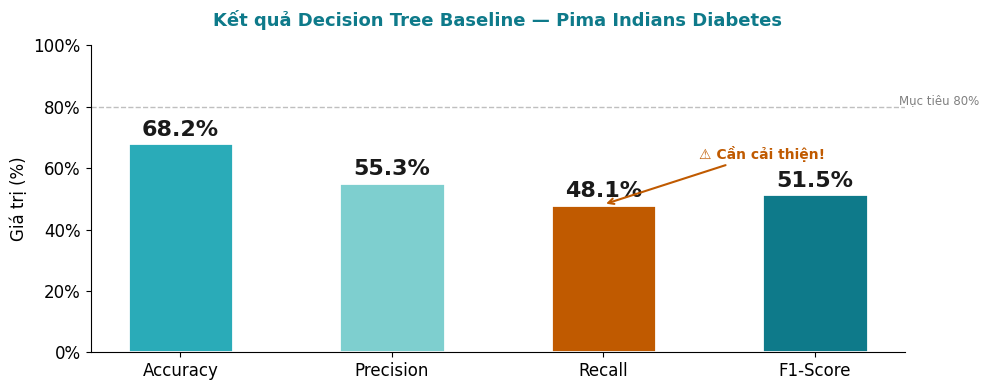

In [15]:
# ── Biểu đồ kết quả ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))

metrics_names  = ["Accuracy", "Precision", "Recall", "F1-Score"]
metrics_vals   = [acc_b, prec_b, rec_b, f1_b]
metrics_colors = ["#2AABB8", "#7ECFCF", "#C05A00", "#0E7A8A"]

bars = ax.bar(metrics_names, [v*100 for v in metrics_vals],
              color=metrics_colors, width=0.5, edgecolor="white", linewidth=2)

for bar, val in zip(bars, metrics_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{val*100:.1f}%", ha="center", va="bottom",
            fontsize=16, fontweight="bold", color="#1A1A1A")

ax.annotate("⚠ Cần cải thiện!",
            xy=(2, rec_b*100), xytext=(2.45, rec_b*100 + 15),
            fontsize=10, color="#C05A00", fontweight="bold",
            arrowprops=dict(arrowstyle="->", color="#C05A00", lw=1.5))

ax.set_ylim(0, 100)
ax.set_ylabel("Giá trị (%)", fontsize=12)
ax.set_title("Kết quả Decision Tree Baseline — Pima Indians Diabetes",
             fontsize=13, fontweight="bold", color="#0E7A8A", pad=14)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(labelsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.axhline(y=80, color="gray", linestyle="--", linewidth=1, alpha=0.5)
ax.text(3.4, 81, "Mục tiêu 80%", fontsize=8.5, color="gray")

plt.tight_layout()
plt.show()

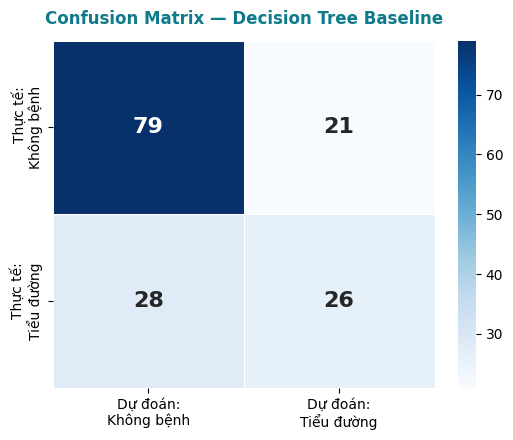

TN = 79  → Đoán đúng người KHÔNG bệnh ✅
FP = 21  → Báo nhầm người lành là bệnh
FN = 28  → BỎ SÓT người bệnh thật ⚠ nguy hiểm nhất!
TP = 26  → Phát hiện đúng người bệnh ✅


In [16]:
# ── Confusion Matrix ─────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_baseline)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Dự đoán:\nKhông bệnh", "Dự đoán:\nTiểu đường"],
            yticklabels=["Thực tế:\nKhông bệnh", "Thực tế:\nTiểu đường"],
            linewidths=0.5, linecolor="white", ax=ax,
            annot_kws={"size": 16, "weight": "bold"})
ax.set_title("Confusion Matrix — Decision Tree Baseline",
             fontsize=12, fontweight="bold", color="#0E7A8A", pad=12)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"TN = {tn}  → Đoán đúng người KHÔNG bệnh ✅")
print(f"FP = {fp}  → Báo nhầm người lành là bệnh")
print(f"FN = {fn}  → BỎ SÓT người bệnh thật ⚠ nguy hiểm nhất!")
print(f"TP = {tp}  → Phát hiện đúng người bệnh ✅")